# U-Net 2.5D (5-slice)
#
Standard U-Net with 5-channel input: adjacent slices [i-2, i-1, i, i+1, i+2] stacked
as a 5-slice context window. Mask is for the centre slice only.
Uses the manifest-based dataset produced by `preprocess_dataset.py`.
#
Stability fixes:
- LR = 1e-4, gradient clipping (max_norm=1.0), cosine annealing
- Checkpoint on best **validation loss**
- Fixed threshold 0.5 for monitoring; full sweep once at the end

In [1]:
%pip uninstall -y torch torchvision torchaudio
%pip install --no-cache-dir torch==2.5.1  torchvision==0.20.1 torchaudio==2.5.1 --index-url https://download.pytorch.org/whl/cu121

Found existing installation: torch 2.10.0+cu128
Uninstalling torch-2.10.0+cu128:
  Successfully uninstalled torch-2.10.0+cu128
Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128
Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.4/780.4 MB 319.9 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 240.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 285.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 317.3 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 335.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import json
import os
from typing import Dict, List, Optional

import albumentations as A
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [3]:
# ---- Paths ----
_kaggle_processed = '/kaggle/input/datasets/sharadprakash117/lung-tumor-processed-for-2d'
_local_processed = os.path.join(os.path.dirname(os.path.abspath('.')), 'lung_tumor_processed')
processed_data_dir = _kaggle_processed if os.path.isdir(_kaggle_processed) else _local_processed

manifest_dir = os.path.join(processed_data_dir, 'manifests')

output_dir = os.path.join(os.getcwd(), 'unet_5_slice_outputs')
checkpoint_dir = os.path.join(output_dir, 'checkpoints')
os.makedirs(checkpoint_dir, exist_ok=True)

num_epochs = 25
batch_size = 16
learning_rate = 1e-4
threshold_metric = 'dice'
num_workers = 0

print(f'processed_data_dir = {processed_data_dir}')
print(f'output_dir         = {output_dir}')

processed_data_dir = /kaggle/input/datasets/sharadprakash117/lung-tumor-processed-for-2d
output_dir         = /kaggle/working/unet_5_slice_outputs


In [4]:
# ---- Dataset (5-slice context window) ----

class ManifestFiveSliceDataset(Dataset):
    """Loads [i-2, i-1, i, i+1, i+2] slices as a 5-channel image; mask is centre slice only."""

    def __init__(self, processed_root: str, manifest_path: str,
                 transform: Optional[A.Compose] = None, use_balanced: bool = True):
        with open(manifest_path) as f:
            manifest = json.load(f)

        self.processed_root = processed_root
        self.split = manifest['split']
        self.samples: List[Dict] = manifest['samples']
        self.transform = transform

        if use_balanced and 'balanced_indices' in manifest:
            self.indices = manifest['balanced_indices']
        else:
            self.indices = list(range(len(self.samples)))

    def __len__(self):
        return len(self.indices)

    def _load_slice(self, patient: str, slice_idx: int) -> np.ndarray:
        path = os.path.join(
            self.processed_root, self.split, patient, 'data', f'{slice_idx}.npy')
        return np.load(path).astype(np.float32)

    def __getitem__(self, idx):
        sample = self.samples[self.indices[idx]]
        patient = sample['patient']
        i = sample['slice_idx']
        n = sample['num_slices']

        idxs = [
            max(0, min(n - 1, i - 2)),
            max(0, min(n - 1, i - 1)),
            i,
            max(0, min(n - 1, i + 1)),
            max(0, min(n - 1, i + 2)),
        ]

        s_m2 = self._load_slice(patient, idxs[0])
        s_m1 = self._load_slice(patient, idxs[1])
        s_0 = self._load_slice(patient, idxs[2])
        s_p1 = self._load_slice(patient, idxs[3])
        s_p2 = self._load_slice(patient, idxs[4])

        mask_path = os.path.join(
            self.processed_root, self.split, patient, 'masks', f'{i}.npy')
        mask = np.load(mask_path).astype(np.float32)
        mask = (mask > 0).astype(np.float32)

        # Stack as (H, W, 5) so albumentations treats all channels identically
        stack_5 = np.stack([s_m2, s_m1, s_0, s_p1, s_p2], axis=-1)

        if self.transform is not None:
            transformed = self.transform(image=stack_5, mask=mask)
            stack_5 = transformed['image']
            mask = transformed['mask']

        # (H, W, 5) -> (5, H, W)
        image = stack_5.transpose(2, 0, 1).astype(np.float32)
        mask = np.expand_dims(mask, axis=0)

        return torch.from_numpy(image), torch.from_numpy(mask)


train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ElasticTransform(alpha=40.0, sigma=5.0, p=0.35),
])

val_test_transform = A.Compose([])

train_dataset = ManifestFiveSliceDataset(
    processed_data_dir,
    os.path.join(manifest_dir, 'train_manifest.json'),
    transform=train_transform, use_balanced=True,
)
val_dataset = ManifestFiveSliceDataset(
    processed_data_dir,
    os.path.join(manifest_dir, 'val_manifest.json'),
    transform=val_test_transform, use_balanced=True,
)
test_dataset = ManifestFiveSliceDataset(
    processed_data_dir,
    os.path.join(manifest_dir, 'test_manifest.json'),
    transform=val_test_transform, use_balanced=False,
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

print(f'Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}')

Train: 2902 | Val: 174 | Test: 1335


In [5]:
# ---- Loss ----

class TverskyLoss(nn.Module):
    def __init__(self, alpha=0.3, beta=0.7, smooth=1e-6):
        super().__init__()
        self.alpha = alpha
        self.beta = beta
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits).view(-1)
        targets_f = targets.view(-1)

        tp = (probs * targets_f).sum()
        fp = ((1.0 - targets_f) * probs).sum()
        fn = (targets_f * (1.0 - probs)).sum()

        tversky = (tp + self.smooth) / (tp + self.alpha * fn + self.beta * fp + self.smooth)
        return 1.0 - tversky

In [6]:
# ---- Model ----

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.double_conv(x)


class UNetBaseline(nn.Module):
    def __init__(self, in_channels=5, out_channels=1):
        super().__init__()
        self.inc = DoubleConv(in_channels, 64)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(64, 128))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(128, 256))
        self.down3 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(256, 512))

        self.up1 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.conv_up1 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv_up2 = DoubleConv(256, 128)

        self.up3 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv_up3 = DoubleConv(128, 64)

        self.outc = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)

        x = self.up1(x4)
        x = torch.cat([x3, x], dim=1)
        x = self.conv_up1(x)

        x = self.up2(x)
        x = torch.cat([x2, x], dim=1)
        x = self.conv_up2(x)

        x = self.up3(x)
        x = torch.cat([x1, x], dim=1)
        x = self.conv_up3(x)

        return self.outc(x)

In [7]:
# ---- Metrics ----

def dice_score_from_binary(pred_bin, target_bin, smooth=1e-6):
    pred_f = pred_bin.reshape(-1)
    target_f = target_bin.reshape(-1)
    intersection = np.sum(pred_f * target_f)
    return (2.0 * intersection + smooth) / (np.sum(pred_f) + np.sum(target_f) + smooth)


def iou_score_from_binary(pred_bin, target_bin, smooth=1e-6):
    pred_f = pred_bin.reshape(-1)
    target_f = target_bin.reshape(-1)
    intersection = np.sum(pred_f * target_f)
    union = np.sum(pred_f) + np.sum(target_f) - intersection
    return (intersection + smooth) / (union + smooth)


def find_optimal_threshold(val_probs, val_masks, thresholds=None, metric='dice', smooth=1e-6):
    if thresholds is None:
        thresholds = np.round(np.arange(0.05, 1.0, 0.05), 2)

    probs_np = val_probs.detach().cpu().numpy() if torch.is_tensor(val_probs) else np.asarray(val_probs)
    masks_np = val_masks.detach().cpu().numpy() if torch.is_tensor(val_masks) else np.asarray(val_masks)
    masks_np = (masks_np > 0.5).astype(np.float32)

    score_fn = dice_score_from_binary if metric.lower() == 'dice' else iou_score_from_binary

    best_threshold, best_score = float(thresholds[0]), -1.0
    threshold_to_score = {}
    for thr in thresholds:
        pred_bin = (probs_np >= thr).astype(np.float32)
        score = score_fn(pred_bin, masks_np, smooth=smooth)
        threshold_to_score[float(thr)] = float(score)
        if score > best_score:
            best_score = float(score)
            best_threshold = float(thr)

    return best_threshold, best_score, threshold_to_score


def compute_roc_diagnostics(val_probs, val_masks):
    probs_np = val_probs.detach().cpu().numpy() if torch.is_tensor(val_probs) else np.asarray(val_probs)
    masks_np = val_masks.detach().cpu().numpy() if torch.is_tensor(val_masks) else np.asarray(val_masks)

    y_score = probs_np.reshape(-1)
    y_true = (masks_np.reshape(-1) > 0.5).astype(np.uint8)

    if np.unique(y_true).size < 2:
        return {k: None for k in [
            'roc_auc', 'youden_threshold', 'fpr', 'tpr',
            'pr_auc', 'pr_precision', 'pr_recall',
            'best_pr_threshold', 'best_pr_f1',
        ]}

    fpr, tpr, roc_thresholds = roc_curve(y_true, y_score)
    roc_auc = roc_auc_score(y_true, y_score)

    youden_j = tpr - fpr
    valid_mask = np.isfinite(roc_thresholds) & (roc_thresholds >= 0) & (roc_thresholds <= 1)
    if np.any(valid_mask):
        valid_idx = np.where(valid_mask)[0]
        best_idx = valid_idx[int(np.argmax(youden_j[valid_mask]))]
        youden_threshold = float(roc_thresholds[best_idx])
    else:
        youden_threshold = None

    pr_precision, pr_recall, pr_thresholds = precision_recall_curve(y_true, y_score)
    pr_auc = average_precision_score(y_true, y_score)

    best_pr_threshold, best_pr_f1 = None, None
    if pr_thresholds.size > 0:
        p = pr_precision[:-1]
        r = pr_recall[:-1]
        f1 = np.nan_to_num(2.0 * p * r / (p + r + 1e-8))
        best_pr_idx = int(np.argmax(f1))
        best_pr_threshold = float(pr_thresholds[best_pr_idx])
        best_pr_f1 = float(f1[best_pr_idx])

    return {
        'roc_auc': float(roc_auc),
        'youden_threshold': youden_threshold,
        'fpr': fpr, 'tpr': tpr,
        'pr_auc': float(pr_auc),
        'pr_precision': pr_precision, 'pr_recall': pr_recall,
        'best_pr_threshold': best_pr_threshold,
        'best_pr_f1': best_pr_f1,
    }

In [8]:
# ---- Training ----

def train_and_validate(model, train_loader, val_loader, num_epochs=25,
                       lr=1e-4, checkpoint_dir='checkpoints'):
    model.to(device)
    criterion = TverskyLoss(alpha=0.3, beta=0.7)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)

    best_ckpt_path = os.path.join(checkpoint_dir, 'unet_5_slice_best.pth')

    history = {
        'train_loss': [], 'val_loss': [],
        'train_dice': [], 'val_dice': [],
        'val_iou': [], 'lr': [],
    }
    best_val_loss = float('inf')

    for epoch in range(num_epochs):
        model.train()
        train_loss_sum = 0.0
        train_dice_sum = 0.0

        for images, masks in tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Train]'):
            images, masks = images.to(device), masks.to(device)

            optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, masks)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss_sum += loss.item()
            with torch.no_grad():
                probs = torch.sigmoid(logits)
                pred = (probs > 0.5).float()
                inter = (pred * masks).sum()
                train_dice_sum += (2.0 * inter + 1e-6) / (pred.sum() + masks.sum() + 1e-6)

        scheduler.step()
        avg_train_loss = train_loss_sum / len(train_loader)
        avg_train_dice = (train_dice_sum / len(train_loader)).item()

        model.eval()
        val_loss_sum = 0.0
        val_dice_sum = 0.0
        val_iou_sum = 0.0
        n_val = 0

        with torch.no_grad():
            for images, masks in tqdm(val_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Val]'):
                images, masks = images.to(device), masks.to(device)
                logits = model(images)
                val_loss_sum += criterion(logits, masks).item()

                probs = torch.sigmoid(logits)
                pred = (probs > 0.5).float()
                inter = (pred * masks).sum()
                val_dice_sum += (2.0 * inter + 1e-6) / (pred.sum() + masks.sum() + 1e-6)
                val_iou_sum += (inter + 1e-6) / (pred.sum() + masks.sum() - inter + 1e-6)
                n_val += 1

        avg_val_loss = val_loss_sum / n_val
        avg_val_dice = (val_dice_sum / n_val).item()
        avg_val_iou = (val_iou_sum / n_val).item()
        current_lr = optimizer.param_groups[0]['lr']

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['train_dice'].append(avg_train_dice)
        history['val_dice'].append(avg_val_dice)
        history['val_iou'].append(avg_val_iou)
        history['lr'].append(current_lr)

        improved = ''
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save({
                'model_state_dict': model.state_dict(),
                'epoch': epoch + 1,
                'val_loss': avg_val_loss,
            }, best_ckpt_path)
            improved = ' *'

        print(
            f'Epoch {epoch+1}/{num_epochs} | '
            f'Train Loss: {avg_train_loss:.4f} | Train Dice: {avg_train_dice:.4f} | '
            f'Val Loss: {avg_val_loss:.4f} | Val Dice@0.5: {avg_val_dice:.4f} | '
            f'Val IoU@0.5: {avg_val_iou:.4f} | LR: {current_lr:.2e}{improved}'
        )

    ckpt = torch.load(best_ckpt_path, map_location=device)
    model.load_state_dict(ckpt['model_state_dict'])
    print(f"\nBest checkpoint: epoch {ckpt['epoch']} | val_loss={ckpt['val_loss']:.4f}")
    return model, history, best_ckpt_path

In [9]:
# ---- Final threshold sweep ----

def final_threshold_sweep(model, val_loader, metric='dice'):
    model.to(device)
    model.eval()
    all_probs, all_masks = [], []
    with torch.no_grad():
        for images, masks in tqdm(val_loader, desc='Val sweep'):
            images = images.to(device)
            probs = torch.sigmoid(model(images)).cpu()
            all_probs.append(probs)
            all_masks.append(masks)

    val_probs = torch.cat(all_probs, dim=0)
    val_masks = torch.cat(all_masks, dim=0)

    best_thr, best_score, thr_to_score = find_optimal_threshold(val_probs, val_masks, metric=metric)
    roc_diag = compute_roc_diagnostics(val_probs, val_masks)

    print(f'Optimal threshold ({metric.upper()}): {best_thr:.2f} | Score: {best_score:.4f}')
    roc_text = f"{roc_diag['roc_auc']:.4f}" if roc_diag['roc_auc'] is not None else 'N/A'
    pr_text = f"{roc_diag['pr_auc']:.4f}" if roc_diag['pr_auc'] is not None else 'N/A'
    print(f'ROC-AUC: {roc_text} | PR-AUC: {pr_text}')

    return best_thr, best_score, thr_to_score, roc_diag

In [10]:
# ---- Test evaluation + overlays ----

def evaluate_test(model, test_loader, save_dir, threshold=0.5):
    model.to(device)
    model.eval()

    with_gt_dir = os.path.join(save_dir, 'with_gt')
    without_gt_dir = os.path.join(save_dir, 'without_gt')
    os.makedirs(with_gt_dir, exist_ok=True)
    os.makedirs(without_gt_dir, exist_ok=True)

    smooth = 1e-6
    total_inter = 0.0
    total_pred_pix = 0.0
    total_mask_pix = 0.0
    total_pos = 0
    detected_pos = 0
    dice_pos_sum = 0.0
    iou_pos_sum = 0.0
    n_pos = 0

    with torch.no_grad():
        for batch_idx, (images, masks) in enumerate(tqdm(test_loader, desc='Testing')):
            images, masks = images.to(device), masks.to(device)
            probs = torch.sigmoid(model(images))
            preds = (probs > threshold).float()

            for b in range(images.size(0)):
                # Use centre channel for visualisation
                img_np = images[b, 2].cpu().numpy()
                gt_np = masks[b, 0].cpu().numpy()
                pred_np = preds[b, 0].cpu().numpy()

                has_gt = gt_np.max() > 0
                has_pred = pred_np.max() > 0

                inter_s = (pred_np * gt_np).sum()
                total_inter += inter_s
                total_pred_pix += pred_np.sum()
                total_mask_pix += gt_np.sum()

                if has_gt:
                    total_pos += 1
                    d = (2.0 * inter_s + smooth) / (pred_np.sum() + gt_np.sum() + smooth)
                    iu = (inter_s + smooth) / (pred_np.sum() + gt_np.sum() - inter_s + smooth)
                    dice_pos_sum += d
                    iou_pos_sum += iu
                    n_pos += 1
                    if inter_s > 0:
                        detected_pos += 1

                if has_gt or has_pred:
                    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
                    axes[0].imshow(img_np, cmap='gray')
                    axes[0].set_title('CT Slice (centre)')
                    axes[0].axis('off')

                    overlay = np.stack([img_np] * 3, axis=-1)
                    overlay = np.clip(overlay, 0, 1)
                    overlay[gt_np > 0] = [0, 1, 0]
                    overlay[pred_np > 0] = [1, 0, 0]
                    both = (gt_np > 0) & (pred_np > 0)
                    overlay[both] = [1, 1, 0]

                    slice_dice = (2.0 * inter_s + smooth) / (pred_np.sum() + gt_np.sum() + smooth)
                    axes[1].imshow(overlay)
                    axes[1].set_title(f'GT(green) Pred(red) Overlap(yellow) | Dice={slice_dice:.4f}')
                    axes[1].axis('off')
                    plt.tight_layout()

                    dest = with_gt_dir if has_gt else without_gt_dir
                    plt.savefig(os.path.join(dest, f'b{batch_idx}_s{b}.png'), dpi=100)
                    plt.close()

    global_dice = (2.0 * total_inter + smooth) / (total_pred_pix + total_mask_pix + smooth)
    global_iou = (total_inter + smooth) / (total_pred_pix + total_mask_pix - total_inter + smooth)
    detection_rate = detected_pos / (total_pos + smooth)
    mean_dice_pos = dice_pos_sum / (n_pos + smooth)
    mean_iou_pos = iou_pos_sum / (n_pos + smooth)

    metrics = {
        'threshold': float(threshold),
        'global_dice': float(global_dice),
        'global_iou': float(global_iou),
        'detection_rate': float(detection_rate),
        'detected': int(detected_pos),
        'total_pos': int(total_pos),
        'mean_dice_pos': float(mean_dice_pos),
        'mean_iou_pos': float(mean_iou_pos),
    }

    print(f"\nGlobal Dice: {global_dice:.4f} | Global IoU: {global_iou:.4f}")
    print(f"Detection rate: {detection_rate:.4f} ({detected_pos}/{total_pos})")
    print(f"Mean Dice (pos): {mean_dice_pos:.4f} | Mean IoU (pos): {mean_iou_pos:.4f}")
    return metrics


def evaluate_test_threshold_sweep(model, test_loader, thresholds=None):
    if thresholds is None:
        thresholds = np.round(np.arange(0.05, 1.0, 0.05), 2)

    model.to(device)
    model.eval()
    smooth = 1e-6

    all_probs, all_masks = [], []
    with torch.no_grad():
        for images, masks in tqdm(test_loader, desc='Collecting test probs'):
            probs = torch.sigmoid(model(images.to(device))).cpu()
            all_probs.append(probs)
            all_masks.append(masks)

    all_probs = torch.cat(all_probs, dim=0).numpy()
    all_masks = (torch.cat(all_masks, dim=0).numpy() > 0.5).astype(np.float32)

    results = []
    for thr in thresholds:
        preds = (all_probs >= thr).astype(np.float32)
        preds_f, masks_f = preds.reshape(-1), all_masks.reshape(-1)

        inter = np.sum(preds_f * masks_f)
        pred_sum, mask_sum = np.sum(preds_f), np.sum(masks_f)

        g_dice = (2.0 * inter + smooth) / (pred_sum + mask_sum + smooth)
        g_iou = (inter + smooth) / (pred_sum + mask_sum - inter + smooth)

        total_pos, detected_pos = 0, 0
        for i in range(all_probs.shape[0]):
            gt = all_masks[i].reshape(-1)
            if gt.sum() > 0:
                total_pos += 1
                if np.sum(preds[i].reshape(-1) * gt) > 0:
                    detected_pos += 1

        results.append({
            'threshold': float(thr), 'global_dice': float(g_dice), 'global_iou': float(g_iou),
            'detection_rate': float(detected_pos / (total_pos + smooth)),
            'detected': int(detected_pos), 'total_pos': int(total_pos),
        })
    return results

In [ ]:
# ---- Run training ----

model = UNetBaseline(in_channels=5, out_channels=1)
model, history, best_ckpt_path = train_and_validate(
    model, train_loader, val_loader,
    num_epochs=num_epochs, lr=learning_rate,
    checkpoint_dir=checkpoint_dir,
)

Epoch 1/25 [Train]:   0%|          | 0/182 [00:00<?, ?it/s]

Epoch 1/25 [Val]:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch 1/25 | Train Loss: 0.9884 | Train Dice: 0.0610 | Val Loss: 0.9926 | Val Dice@0.5: 0.0449 | Val IoU@0.5: 0.0231 | LR: 9.96e-05 *


Epoch 2/25 [Train]:   0%|          | 0/182 [00:00<?, ?it/s]

Epoch 2/25 [Val]:   0%|          | 0/11 [00:00<?, ?it/s]

...

Epoch 23/25 | Train Loss: 0.2201 | Train Dice: 0.7702 | Val Loss: 0.3906 | Val Dice@0.5: 0.6047 | Val IoU@0.5: 0.4394 | LR: 2.56e-06


Epoch 24/25 [Train]:   0%|          | 0/182 [00:00<?, ?it/s]

Epoch 24/25 [Val]:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch 24/25 | Train Loss: 0.2145 | Train Dice: 0.7784 | Val Loss: 0.3824 | Val Dice@0.5: 0.6280 | Val IoU@0.5: 0.4619 | LR: 1.39e-06


Epoch 25/25 [Train]:   0%|          | 0/182 [00:00<?, ?it/s]

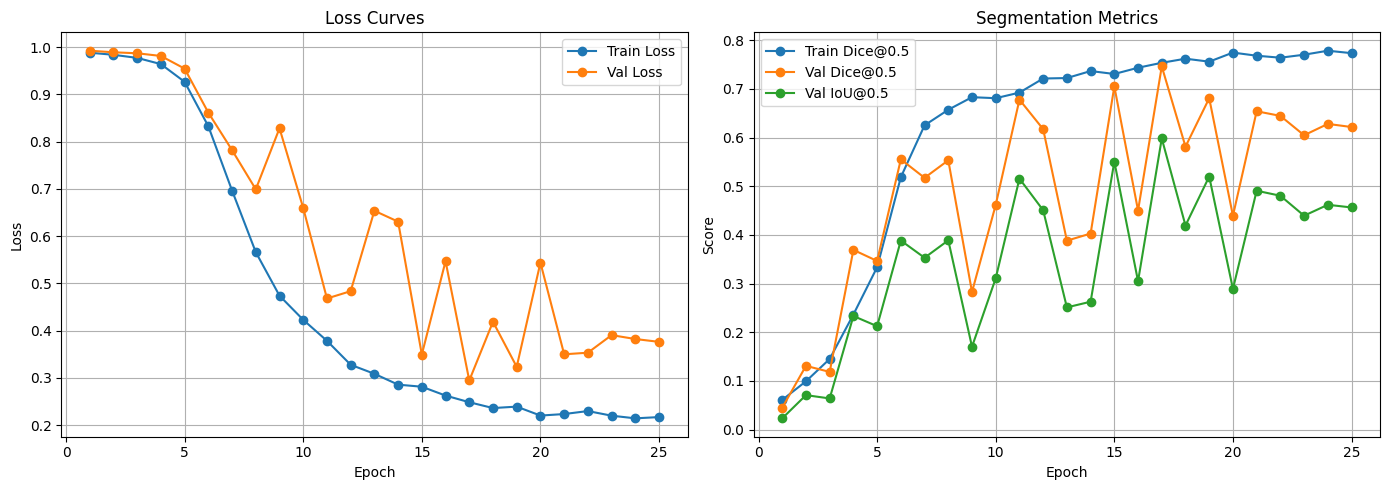

In [18]:
# ---- Training curves ----

epochs_range = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(epochs_range, history['train_loss'], marker='o', label='Train Loss')
axes[0].plot(epochs_range, history['val_loss'], marker='o', label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss Curves')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs_range, history['train_dice'], marker='o', label='Train Dice@0.5')
axes[1].plot(epochs_range, history['val_dice'], marker='o', label='Val Dice@0.5')
axes[1].plot(epochs_range, history['val_iou'], marker='o', label='Val IoU@0.5')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Score')
axes[1].set_title('Segmentation Metrics')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'training_curves.png'), dpi=150)
plt.show()

Val sweep:   0%|          | 0/11 [00:00<?, ?it/s]

Optimal threshold (DICE): 0.15 | Score: 0.7518
ROC-AUC: 0.9106 | PR-AUC: 0.7183
Checkpoint updated with threshold=0.15


/tmp/ipykernel_55/3315398085.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(best_ckpt_path, map_location=device)


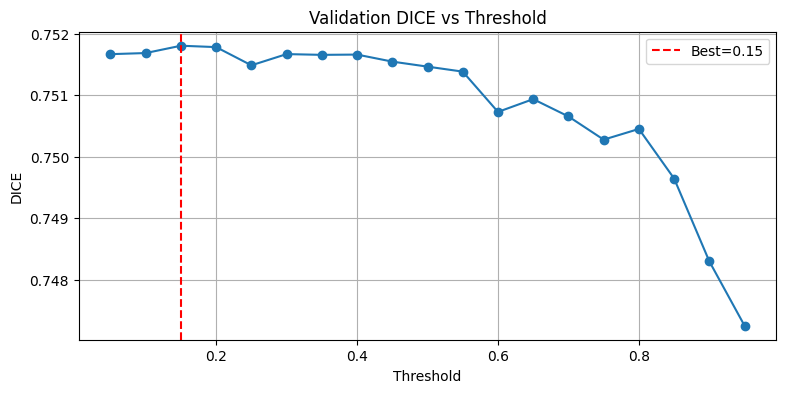

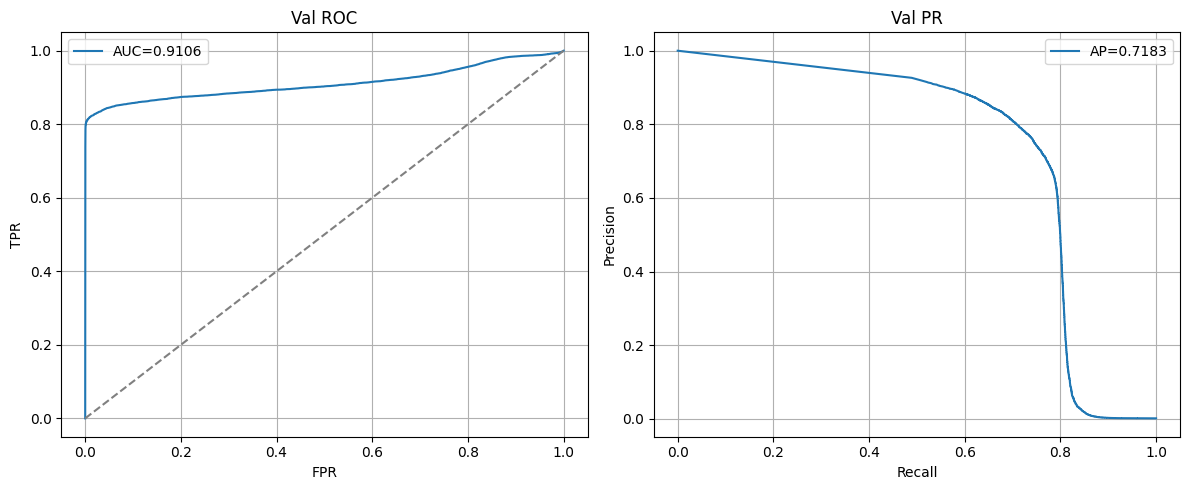

In [17]:
# ---- Final threshold sweep on validation set ----

best_thr, best_score, thr_to_score, roc_diag = final_threshold_sweep(model, val_loader, metric=threshold_metric)

ckpt = torch.load(best_ckpt_path, map_location=device)
ckpt['threshold'] = best_thr
ckpt['threshold_score'] = best_score
ckpt['threshold_metric'] = threshold_metric
torch.save(ckpt, best_ckpt_path)
print(f'Checkpoint updated with threshold={best_thr:.2f}')

plt.figure(figsize=(9, 4))
plt.plot(list(thr_to_score.keys()), list(thr_to_score.values()), marker='o')
plt.axvline(best_thr, color='red', linestyle='--', label=f'Best={best_thr:.2f}')
plt.xlabel('Threshold')
plt.ylabel(threshold_metric.upper())
plt.title(f'Validation {threshold_metric.upper()} vs Threshold')
plt.grid(True)
plt.legend()
plt.savefig(os.path.join(output_dir, 'val_threshold_sweep.png'), dpi=150)
plt.show()

if roc_diag['fpr'] is not None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].plot(roc_diag['fpr'], roc_diag['tpr'], label=f"AUC={roc_diag['roc_auc']:.4f}")
    axes[0].plot([0, 1], [0, 1], '--', color='gray')
    axes[0].set_title('Val ROC')
    axes[0].set_xlabel('FPR')
    axes[0].set_ylabel('TPR')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(roc_diag['pr_recall'], roc_diag['pr_precision'], label=f"AP={roc_diag['pr_auc']:.4f}")
    axes[1].set_title('Val PR')
    axes[1].set_xlabel('Recall')
    axes[1].set_ylabel('Precision')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'val_roc_pr.png'), dpi=150)
    plt.show()

In [14]:
# ---- Test evaluation ----

test_metrics = evaluate_test(
    model, test_loader,
    save_dir=os.path.join(output_dir, 'test_overlays'),
    threshold=best_thr,
)


Global Dice: 0.3557 | Global IoU: 0.2163
Detection rate: 0.6040 (61/101)
Mean Dice (pos): 0.4082 | Mean IoU (pos): 0.3268


In [15]:
# ---- Test threshold sweep ----

test_sweep = evaluate_test_threshold_sweep(model, test_loader)

print(f"\n{'Thr':>5}  {'G-Dice':>8}  {'G-IoU':>8}  {'Detect':>8}")
print('-' * 40)
for r in test_sweep:
    print(f"{r['threshold']:>5.2f}  {r['global_dice']:>8.4f}  {r['global_iou']:>8.4f}  {r['detected']:>3d}/{r['total_pos']:<3d}")

best_test_dice = max(test_sweep, key=lambda x: x['global_dice'])
best_test_iou = max(test_sweep, key=lambda x: x['global_iou'])
print(f"\nBest test Dice -> thr={best_test_dice['threshold']:.2f}  Dice={best_test_dice['global_dice']:.4f}")
print(f"Best test IoU  -> thr={best_test_iou['threshold']:.2f}  IoU={best_test_iou['global_iou']:.4f}")


  Thr    G-Dice     G-IoU    Detect
----------------------------------------
 0.05    0.3536    0.2147   61/101
 0.10    0.3540    0.2151   61/101
 0.15    0.3557    0.2163   61/101
 0.20    0.3568    0.2171   60/101
 0.25    0.3575    0.2176   60/101
 0.30    0.3581    0.2181   60/101
 0.35    0.3587    0.2185   60/101
 0.40    0.3587    0.2185   60/101
 0.45    0.3598    0.2193   60/101
 0.50    0.3599    0.2194   60/101
 0.55    0.3602    0.2197   59/101
 0.60    0.3607    0.2200   59/101
 0.65    0.3611    0.2203   59/101
 0.70    0.3617    0.2208   58/101
 0.75    0.3625    0.2214   58/101
 0.80    0.3629    0.2217   58/101
 0.85    0.3638    0.2224   58/101
 0.90    0.3646    0.2229   58/101
 0.95    0.3660    0.2240   58/101

Best test Dice -> thr=0.95  Dice=0.3660
Best test IoU  -> thr=0.95  IoU=0.2240


In [16]:
# ---- Save summary ----

summary = {
    'experiment': 'unet_2_5d_5slice',
    'epochs': num_epochs,
    'lr': learning_rate,
    'batch_size': batch_size,
    'history': history,
    'val_threshold': best_thr,
    'val_threshold_score': best_score,
    'val_threshold_metric': threshold_metric,
    'test_metrics': test_metrics,
    'test_sweep': test_sweep,
}
with open(os.path.join(output_dir, 'summary.json'), 'w') as f:
    json.dump(summary, f, indent=2)

print(f'\nAll outputs saved to {output_dir}')


All outputs saved to /kaggle/working/unet_5_slice_outputs
